# Desafio Data Scientist — Gil Vicente FC
### Análise de dados IMPECT - 8 jogos - época 2025/26

Este notebook apresenta os dois insights encontrados (atacante e defensivo), bem como alguma da exploração feita até chegarmos a algo interpretável.

**Insight 1** — Lançamento lateral como arma ofensiva de bola parada

**Insight 2** — O Gil Vicente contém bem os cruzamentos, com uma exceção clara

## 0. Configuração e carregamento

In [ ]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mplsoccer import Pitch

pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.edgecolor": "#CCCCCC",
})

#Paleta do Gil Vicente FC ---
COR_VERMELHO = "#D52929"
COR_AZUL_MARINHO = "#083363"
COR_DOURADO = "#9EA85E"
COR_CINZA_CLARO = "#D9D9D9"
COR_FUNDO_CAMPO = "#F5F3EE"

def estilizar_eixos(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCCCC")

PASTA_DADOS = "./dados"  # <- ajustar ao caminho local


In [ ]:
ficheiros = sorted(glob.glob(os.path.join(PASTA_DADOS, "*.pkl")))
dfs = [pd.read_pickle(f) for f in ficheiros]
data = pd.concat(dfs, ignore_index=True).sort_values(["matchId", "gameTimeInSec"]).reset_index(drop=True)
print(f"{len(ficheiros)} jogos · {len(data)} eventos · {len(data.columns)} colunas")


8 jogos carregados · 21433 eventos · 236 colunas


**Nota:** as equipas trocam de lado ao intervalo, como no
futebol real. Normalizamos as coordenadas para que fiquem consistentes em
todos os jogos e partes: **negativo = baliza adversária** (o Gil Vicente ataca),
**positivo = baliza do Gil Vicente** (o Gil Vicente defende).


In [ ]:
remates_gv = data[(data["squadName"] == "Gil Vicente FC") & (data["actionType"] == "SHOT")]
sinal = (
    remates_gv.groupby(["matchId", "periodId"])["startCoordinatesX"]
    .mean().apply(lambda x: 1 if x < 0 else -1).rename("multiplicador").reset_index()
)
data = data.merge(sinal, on=["matchId", "periodId"], how="left")
data["multiplicador"] = data["multiplicador"].fillna(1)
for col in ["startCoordinatesX", "startCoordinatesY", "endCoordinatesX", "endCoordinatesY"]:
    if col in data.columns:
        data[col] = data[col] * data["multiplicador"]

data[(data["squadName"] == "Gil Vicente FC") & (data["actionType"] == "SHOT")]     .groupby(["matchId", "periodId"])["startCoordinatesX"].mean().describe()


count    16.000000
mean    -38.212589
std       3.179579
min     -42.166667
25%     -40.568750
50%     -38.683333
75%     -36.752083
max     -30.100000
Name: startCoordinatesX, dtype: float64

In [4]:
jogos = data[["matchId", "dateTime", "homeSquadName", "awaySquadName"]].drop_duplicates()
jogos


,matchId,dateTime,homeSquadName,awaySquadName
0,210999,2026-04-03T14:30:00Z,Gil Vicente FC,Avs Futebol SAD
2805,211014,2026-03-21T18:00:00Z,CD Santa Clara,Gil Vicente FC
5241,211040,2026-04-18T19:30:00Z,Gil Vicente FC,Vitória Guimarães SC
7767,211045,2026-04-13T19:15:00Z,CD Tondela,Gil Vicente FC
10381,211053,2026-04-27T19:15:00Z,Gil Vicente FC,Casa Pia AC
12898,211065,2026-05-03T19:30:00Z,Rio Ave FC,Gil Vicente FC
15632,211072,2026-05-11T19:15:00Z,Gil Vicente FC,FC Arouca
18421,211082,2026-05-16T19:30:00Z,Sporting Lissabon,Gil Vicente FC


---
## 1. Insight 1 — Lançamento lateral como arma ofensiva

### Porque explorei bolas paradas primeiro


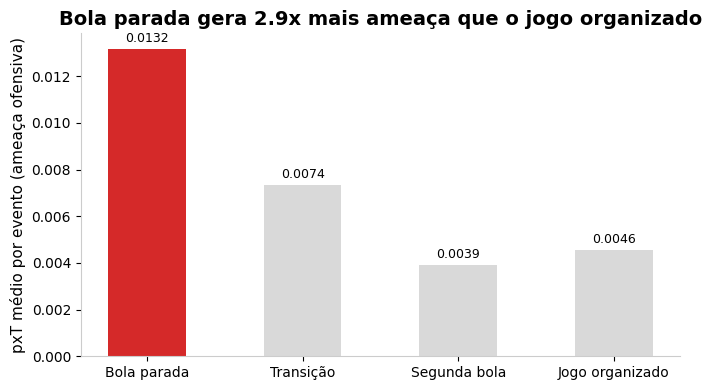

In [5]:
ordem_fases = ["SET_PIECE", "ATTACKING_TRANSITION", "SECOND_BALL", "IN_POSSESSION"]
nomes_fases = {"SET_PIECE": "Bola parada", "ATTACKING_TRANSITION": "Transição",
               "SECOND_BALL": "Segunda bola", "IN_POSSESSION": "Jogo organizado"}
fase_pxt = data[data["squadName"] == "Gil Vicente FC"].groupby("phase")["pxTTeam"].mean()
fase_pxt = fase_pxt.reindex(ordem_fases).reset_index()
fase_pxt["label"] = fase_pxt["phase"].map(nomes_fases)
razao = fase_pxt.loc[fase_pxt["phase"] == "SET_PIECE", "pxTTeam"].values[0]     / fase_pxt.loc[fase_pxt["phase"] == "IN_POSSESSION", "pxTTeam"].values[0]

fig, ax = plt.subplots(figsize=(7, 4))
cores = [COR_VERMELHO if f == "SET_PIECE" else COR_CINZA_CLARO for f in fase_pxt["phase"]]
ax.bar(fase_pxt["label"], fase_pxt["pxTTeam"], color=cores, width=0.5)
for i, v in enumerate(fase_pxt["pxTTeam"]):
    ax.text(i, v + 0.0003, f"{v:.4f}", ha="center", fontsize=9)
ax.set_ylabel("pxT médio por evento (ameaça ofensiva)")
ax.set_title(f"Bola parada gera {razao:.1f}x mais ameaça que o jogo organizado")
estilizar_eixos(ax)
plt.tight_layout()
plt.show()


**pxT** é a métrica nativa do IMPECT para ameaça ofensiva por evento. Os
valores absolutos são pequenos (típico deste tipo de métrica), porém dei maior importância à comparação relativa. Este contraste motivou me decompor as bolas paradas
por tipo.


In [6]:
gv_setpiece = data[(data["squadName"] == "Gil Vicente FC") & (data["phase"] == "SET_PIECE")]
resumo_tipo = gv_setpiece.groupby("setPieceCategory").agg(
    n_eventos=("pxTTeam", "count"), pxt_medio=("pxTTeam", "mean"), golos=("GOALS", "sum")
).sort_values("pxt_medio", ascending=False)
resumo_tipo


,n_eventos,pxt_medio,golos
setPieceCategory,,,
CORNER_LEFT,99,0.022089,0.0
CORNER_RIGHT,207,0.020691,0.0
THROW_IN,556,0.011950,4.0
FREE_KICK,274,0.009613,0.0
GOAL_KICK,55,0.001121,0.0


Os **cantos** têm o pxT médio mais alto por evento (ainda que seja um valor baixo) — mas **zero golos** nos
8 jogos. O **lançamento lateral** tem pxT mais baixo, mas é onde a ameaça se
converte mesmo em golo.


### O ponto crucial

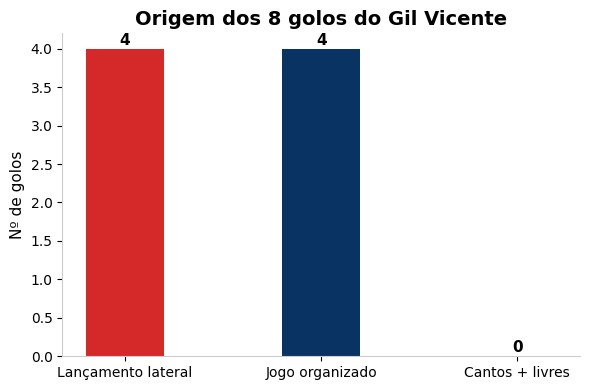


4 de 8 golos (50%) vieram de lançamento lateral


In [7]:
todos_golos_gv = data[(data["squadName"] == "Gil Vicente FC") & (data["GOALS"] > 0)]
golos_sp = todos_golos_gv[todos_golos_gv["phase"] == "SET_PIECE"]
n_throwin = len(golos_sp[golos_sp["setPieceCategory"] == "THROW_IN"])
n_total_golos = len(todos_golos_gv)
n_organizado = n_total_golos - len(golos_sp)
n_corner_livre = len(golos_sp) - n_throwin

fig, ax = plt.subplots(figsize=(6, 4))
categorias = ["Lançamento lateral", "Jogo organizado", "Cantos + livres"]
valores = [n_throwin, n_organizado, n_corner_livre]
ax.bar(categorias, valores, color=[COR_VERMELHO, COR_AZUL_MARINHO, COR_DOURADO], width=0.4)
for i, v in enumerate(valores):
    ax.text(i, v + 0.05, str(v), ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Nº de golos")
ax.set_title(f"Origem dos {n_total_golos} golos do Gil Vicente")
estilizar_eixos(ax)
plt.tight_layout()
plt.show()

print(f"\n{n_throwin} de {n_total_golos} golos ({n_throwin/n_total_golos:.0%}) vieram de lançamento lateral")


### As 4 jogadas de golo

Reconstrução evento-a-evento de cada golo, a partir das coordenadas de cada
ação da jogada, de maneira não só a confirmar como a perceber como foram estes golos. Posteriormente todos os lances foram confirmados por vídeo, no youtube.


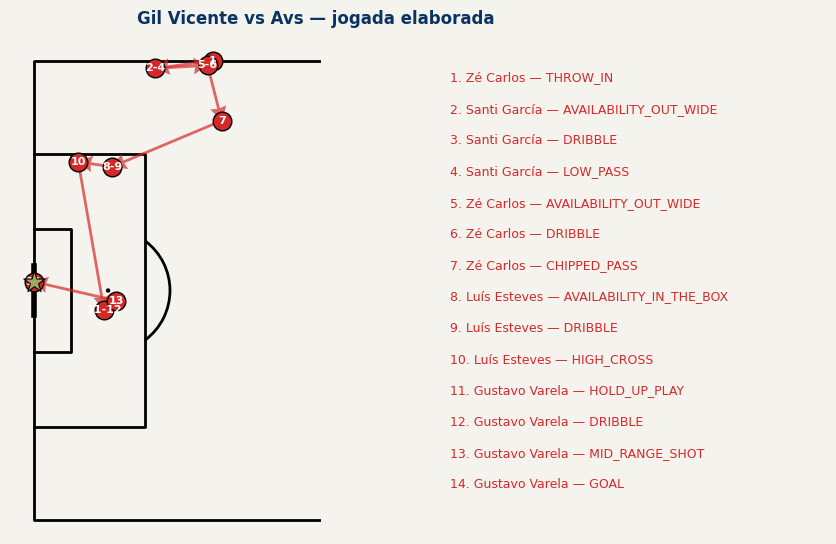

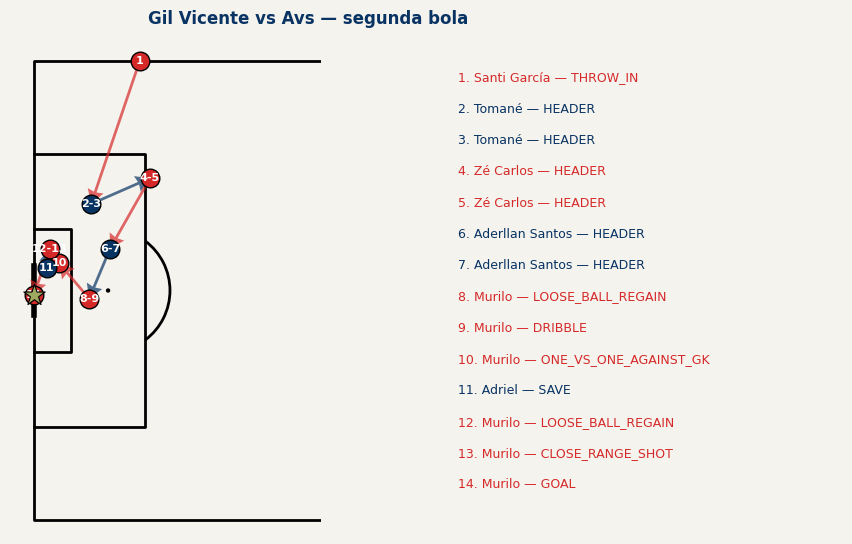

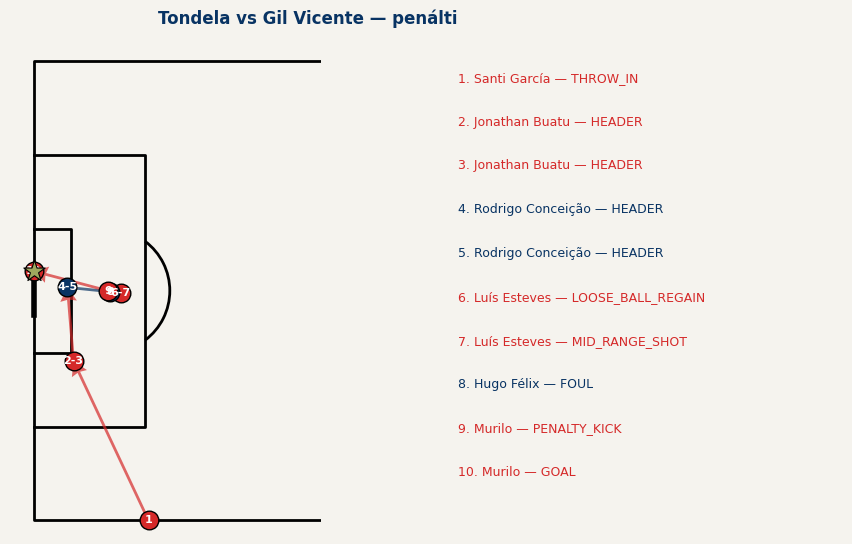

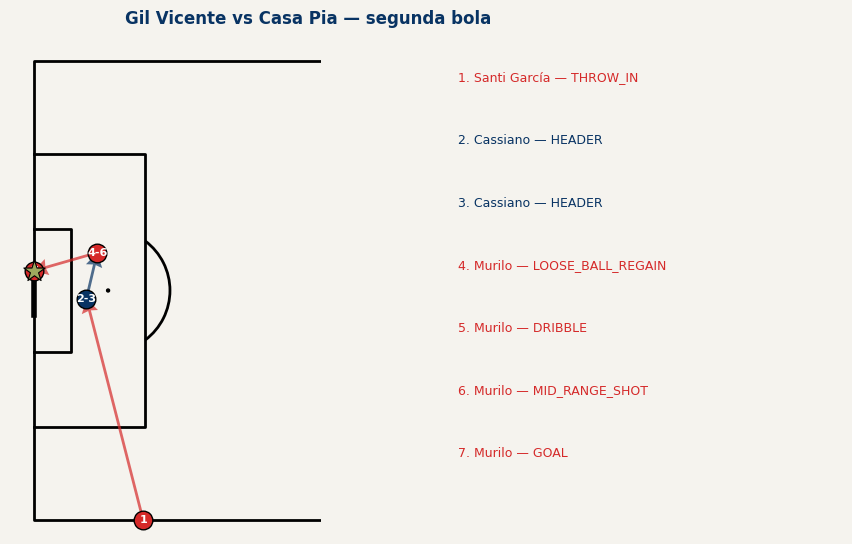

In [8]:
golos_info = [
    {"matchId": 210999, "setPieceSubPhaseId": 90536463.0, "jogo": "Gil Vicente vs Avs — jogada elaborada"},
    {"matchId": 210999, "setPieceSubPhaseId": 90536483.0, "jogo": "Gil Vicente vs Avs — segunda bola"},
    {"matchId": 211045, "setPieceSubPhaseId": 90700672.0, "jogo": "Tondela vs Gil Vicente — penálti"},
    {"matchId": 211053, "setPieceSubPhaseId": 91199882.0, "jogo": "Gil Vicente vs Casa Pia — segunda bola"},
]

def agrupar_pontos_proximos(pontos, limiar_metros=2.0):
    grupos = [[0]]
    for j in range(1, len(pontos)):
        i_ref = grupos[-1][0]
        mesma_equipa = pontos.loc[j, "squadName"] == pontos.loc[i_ref, "squadName"]
        dist = ((pontos.loc[j, "startCoordinatesX"] - pontos.loc[i_ref, "startCoordinatesX"]) ** 2
                + (pontos.loc[j, "startCoordinatesY"] - pontos.loc[i_ref, "startCoordinatesY"]) ** 2) ** 0.5
        if mesma_equipa and dist <= limiar_metros:
            grupos[-1].append(j)
        else:
            grupos.append([j])
    return grupos

def desenhar_jogada(info, seq):
    pontos = seq[["startCoordinatesX", "startCoordinatesY", "squadName", "playerName", "action"]]         .dropna(subset=["startCoordinatesX", "startCoordinatesY"]).reset_index(drop=True)
    grupos = agrupar_pontos_proximos(pontos)

    fig, (ax_campo, ax_legenda) = plt.subplots(1, 2, figsize=(11, 5.5), gridspec_kw={"width_ratios": [2, 1]})
    pitch = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68,
                  pitch_color=COR_FUNDO_CAMPO, line_color="#000000", half=False)
    pitch.draw(ax=ax_campo)

    coords_grupos = [(pontos.loc[g, "startCoordinatesX"].mean(), pontos.loc[g, "startCoordinatesY"].mean()) for g in grupos]
    for g_idx, grupo in enumerate(grupos):
        x0, y0 = coords_grupos[g_idx]
        cor = COR_VERMELHO if pontos.loc[grupo[0], "squadName"] == "Gil Vicente FC" else COR_AZUL_MARINHO
        ax_campo.scatter(x0, y0, color=cor, s=180, zorder=4, edgecolors="black", linewidths=1)
        rotulo = str(grupo[0] + 1) if len(grupo) == 1 else f"{grupo[0]+1}-{grupo[-1]+1}"
        ax_campo.annotate(rotulo, (x0, y0), color="white", fontsize=8, ha="center", va="center", zorder=5, fontweight="bold")
        if g_idx < len(grupos) - 1:
            x1, y1 = coords_grupos[g_idx + 1]
            pitch.arrows(x0, y0, x1, y1, color=cor, ax=ax_campo, width=2, alpha=0.7, headwidth=6)

    ultimo = pontos.iloc[-1]
    ax_campo.scatter(ultimo["startCoordinatesX"], ultimo["startCoordinatesY"], color=COR_DOURADO, s=260,
                      zorder=6, marker="*", edgecolors="black", linewidths=0.8)
    ax_campo.set_xlim((-56, -10) if ultimo["startCoordinatesX"] < 0 else (10, 56))
    ax_campo.set_ylim(-36, 36)

    ax_legenda.axis("off")
    ax_legenda.set_xlim(0, 1); ax_legenda.set_ylim(0, 1)
    y = 0.95
    for j in range(len(pontos)):
        cor = COR_VERMELHO if pontos.loc[j, "squadName"] == "Gil Vicente FC" else COR_AZUL_MARINHO
        ax_legenda.text(0.02, y, f"{j+1}. {pontos.loc[j, 'playerName']} — {pontos.loc[j, 'action']}", color=cor, fontsize=9, va="top")
        y -= 0.9 / max(len(pontos), 1)

    fig.suptitle(info["jogo"], color=COR_AZUL_MARINHO, fontsize=12, fontweight="bold")
    fig.patch.set_facecolor(COR_FUNDO_CAMPO)
    plt.tight_layout()
    plt.show()

for info in golos_info:
    seq = data[(data["matchId"] == info["matchId"]) & (data["setPieceSubPhaseId"] == info["setPieceSubPhaseId"])].sort_values("gameTimeInSec")
    if len(seq) > 0:
        desenhar_jogada(info, seq)


### Padrão individual
Quis ainda saber se há alguma padrão individual, ou seja, se há alguem com maior tendência a criar perigo neste tipo de lances.

In [9]:
c1 = (data["squadName"] == "Gil Vicente FC").fillna(False)
c2 = (data["actionType"] == "THROW_IN").fillna(False)
lancamentos = data[c1 & c2]

registos = []
for _, lanc in lancamentos.iterrows():
    match_id, t_lanc = lanc["matchId"], lanc["gameTimeInSec"]
    c1b = (data["matchId"] == match_id).fillna(False)
    c2b = (data["gameTimeInSec"] > t_lanc).fillna(False)
    c3b = (data["gameTimeInSec"] <= t_lanc + 15).fillna(False)
    janela = data[c1b & c2b & c3b]
    c4b = (janela["actionType"] == "SHOT").fillna(False)
    c5b = (janela["squadName"] == "Gil Vicente FC").fillna(False)
    remates = janela[c4b & c5b]
    registos.append({"lancador": lanc["playerName"], "houve_remate": len(remates) > 0, "distancia": lanc["passDistance"]})

res_lancador = pd.DataFrame(registos)
resumo_lancador = res_lancador.groupby("lancador").agg(
    n=("houve_remate", "count"), taxa_remate=("houve_remate", "mean"), distancia_media=("distancia", "mean")
).sort_values("n", ascending=False)
resumo_lancador[resumo_lancador["n"] >= 5]


,n,taxa_remate,distancia_media
lancador,,,
Ghislain Konan,59,0.033898,15.961017
Zé Carlos,43,0.069767,19.258140
Santi García,29,0.310345,23.431034
Hevertton,16,0.062500,23.681250
Jonathan Mutombo,10,0.000000,15.190000


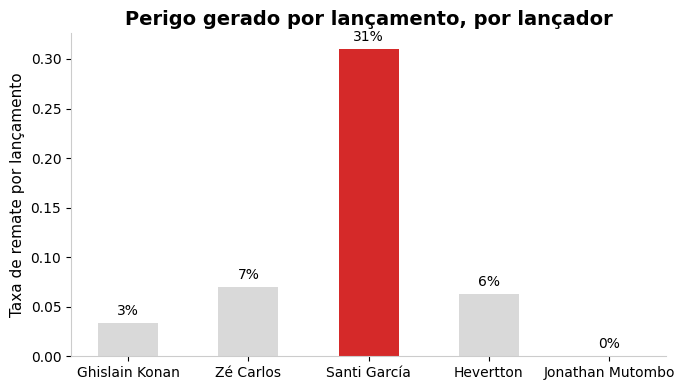

In [10]:
dados_grafico = resumo_lancador[resumo_lancador["n"] >= 5].reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
cores = [COR_VERMELHO if l == "Santi García" else COR_CINZA_CLARO for l in dados_grafico["lancador"]]
ax.bar(dados_grafico["lancador"], dados_grafico["taxa_remate"], color=cores, width=0.5)
for i, v in enumerate(dados_grafico["taxa_remate"]):
    ax.text(i, v + 0.008, f"{v:.0%}", ha="center", fontsize=10)
ax.set_ylabel("Taxa de remate por lançamento")
ax.set_title("Perigo gerado por lançamento, por lançador")
estilizar_eixos(ax)
plt.tight_layout()
plt.show()


O **Santi García** converte 31% dos seus lançamentos em remate, quase 9x
mais que o Ghislain Konan (3.4%), o lançador mais utilizado. Ele lança a
distâncias parecidas com o Hevertton (23.4m vs. 23.7m em média), que só
converte 6.25%. Assim vemos que a diferença não é a distância, mas sim o jogador.


### Validação estatística - Aplicação de um modelo de Machine Learning.

Um modelo de regressão logística confirma que o efeito do Santi García se
mantém mesmo controlando pela distância do lançamento.


In [11]:
import statsmodels.formula.api as smf

registos_modelo = []
for _, lanc in lancamentos.iterrows():
    match_id, t_lanc = lanc["matchId"], lanc["gameTimeInSec"]
    c1b = (data["matchId"] == match_id).fillna(False)
    c2b = (data["gameTimeInSec"] > t_lanc).fillna(False)
    c3b = (data["gameTimeInSec"] <= t_lanc + 15).fillna(False)
    janela = data[c1b & c2b & c3b]
    c4b = (janela["actionType"] == "SHOT").fillna(False)
    c5b = (janela["squadName"] == "Gil Vicente FC").fillna(False)
    houve_remate = (c4b & c5b).any()
    registos_modelo.append({
        "resultou_em_remate": int(houve_remate),
        "e_santi_garcia": 1 if lanc["playerName"] == "Santi García" else 0,
        "distancia": lanc["passDistance"],
        "lado_esquerda": 1 if lanc["startCoordinatesY"] < 0 else 0,
    })

df_modelo = pd.DataFrame(registos_modelo).dropna()
modelo = smf.logit("resultou_em_remate ~ e_santi_garcia + distancia + lado_esquerda", data=df_modelo).fit(disp=0)

odds_ratios = pd.DataFrame({
    "odds_ratio": modelo.params.apply(lambda x: 2.718281828 ** x).round(2),
    "p_valor": modelo.pvalues.round(4),
})
odds_ratios


,odds_ratio,p_valor
Intercept,0.01,0.0000
e_santi_garcia,8.69,0.0003
distancia,1.05,0.1932
lado_esquerda,2.12,0.2302


O modelo é estatisticamente significativo (LLR p-value < 0.001). O único
preditor claramente significativo é **ser o Santi García** (odds ratio 8.7,
p<0.001). Nem a distância nem o lado do lançamento têm efeito
estatisticamente distinguível de zero quando o jogador já está no modelo.


### Qualidade, não volume
Fiquei ainda com a dúvida de o Gil Vicente ter lançado muitas vezes, e por isso, fez mais golos. Para isso, fui tentar perceber essa questão na secção seguinte.

In [12]:
LIMIAR_LONGO = 24.5

def analisar_equipa(nome_equipa, data, subset_jogos=None):
    c1 = (data["squadName"] == nome_equipa).fillna(False)
    c2 = (data["actionType"] == "THROW_IN").fillna(False)
    base = data[c1 & c2 & data["matchId"].isin(subset_jogos)] if subset_jogos is not None else data[c1 & c2]
    total = len(base)
    longos = base[base["passDistance"] > LIMIAR_LONGO]
    n_longos = len(longos)

    n_com_remate = 0
    for _, lanc in longos.iterrows():
        match_id, t_lanc = lanc["matchId"], lanc["gameTimeInSec"]
        c1b = (data["matchId"] == match_id).fillna(False)
        c2b = (data["gameTimeInSec"] > t_lanc).fillna(False)
        c3b = (data["gameTimeInSec"] <= t_lanc + 15).fillna(False)
        janela = data[c1b & c2b & c3b]
        c4b = (janela["actionType"] == "SHOT").fillna(False)
        c5b = (janela["squadName"] == nome_equipa).fillna(False)
        if (c4b & c5b).any():
            n_com_remate += 1

    return {
        "equipa": nome_equipa, "total_lancamentos": total, "pct_longos": n_longos / total if total else None,
        "taxa_conversao_longos": n_com_remate / n_longos if n_longos else None,
    }

mapa_adversario = (
    data[(data["squadName"] != "Gil Vicente FC").fillna(False)][["matchId", "squadName"]]
    .drop_duplicates().dropna().groupby("matchId")["squadName"].first().to_dict()
)

resultados = [analisar_equipa("Gil Vicente FC", data)]
for match_id, nome in mapa_adversario.items():
    resultados.append(analisar_equipa(nome, data, subset_jogos=[match_id]))

res_df = pd.DataFrame(resultados)
res_df


,equipa,total_lancamentos,pct_longos,taxa_conversao_longos
0,Gil Vicente FC,164,0.237805,0.153846
1,Avs Futebol SAD,16,0.687500,0.090909
2,CD Santa Clara,33,0.242424,0.000000
3,Vitória Guimarães SC,26,0.038462,0.000000
4,CD Tondela,21,0.142857,0.000000
5,Casa Pia AC,16,0.437500,0.142857
6,Rio Ave FC,26,0.153846,0.000000
7,FC Arouca,22,0.454545,0.100000
8,Sporting Lissabon,8,0.000000,NaN


O Gil Vicente tenta **menos** lançamentos longos que a média dos adversários
(23.8% vs. 27.0% do volume) mas converte-os em remate a uma taxa **3.2x
superior** (15.4% vs. 4.8%). Logo não é sobre insistir mais, mas sim sobre fazê-lo bem.


### Síntese — Insight 1

**Questão:** que tipo de bola parada é mais eficaz para o Gil Vicente, sabendo que é uma fase de jogo em que criam bastante perigo?

**Evidência:** 50% dos golos (4 de 8) vieram de lançamento lateral, mais do
que cantos e livres combinados apesar de muito menos volume de eventos.

Validado com regressão logística: o efeito do lançador Santi García
(odds ratio 8.7, p<0.001) sobrevive ao controlar pela distância, é técnica,
não volume nem alcance.

**Interpretação futebolística:** o lançamento longo funciona, na prática,
como uma bola parada semi-organizada — tal como um canto ou um livre,
suspende o jogo corrido e dá tempo à equipa atacante para montar
movimentações na área, numa fase do jogo em que a maioria das equipas não
tem um plano defensivo tão estruturado como tem para cantos ou livres. A
distinção do Santi García sugere que não é só a suspensão do jogo a criar a
oportunidade — é a qualidade da entrega (colocação, trajetória) a colocar a
bola numa zona mais difícil de aliviar, já que ele gera o mesmo perigo a
distâncias semelhantes às de outros lançadores bem menos eficazes.

**Aplicação prática para uma equipa técnica:** tratar os lançamentos longos
do Gil Vicente (sobretudo quando é o Santi García a executar) com o mesmo
nível de organização defensiva que dariam a um canto ou livre: atribuir
marcações específicas na área antes da bola ser lançada, e destacar um
jogador para "seguir" o Santi García sempre que ele se aproxime da linha
lateral no terço ofensivo, avisando a equipa para se reorganizar como bola
parada.

**Limitações:** 8 golos totais é uma base pequena; o modelo estatístico tem
poder limitado com esta amostra, mas o efeito do lançador é forte o
suficiente para ser claramente significativo mesmo assim.

---
## 2. Insight 2 — Cruzamentos

Esta parte não foi tão direta de chegar, houve várias tentativas de encontrar fragilidades defensivas do Gil Vicente, mas que caíam rapidamente. Por isso apresento na secção a seguir algumas das mesmas.

### O caminho até aqui: tentativas que não resultaram

Antes de chegar aos cruzamentos, testei três hipóteses de fraqueza defensiva
do Gil Vicente. Nenhuma resistiu à comparação com os adversários, mas foi
precisamente esse padrão repetido que me levou a mudar a pergunta.


In [13]:
# Tentativa 1: vulnerabilidade em contra-ataque
golos_sofridos = data[(data["actionType"] == "GOAL") & (data["squadName"] != "Gil Vicente FC") & data["squadName"].notna()]
print(golos_sofridos["phase"].value_counts())


phase
ATTACKING_TRANSITION    6
SET_PIECE               3
IN_POSSESSION           2
Name: count, dtype: int64[pyarrow]


A fase mais comum nos golos sofridos etiquetados como ATTACKING_TRANSITION
pareceu um sinal óbvio de "contra-ataque". Mas ao reconstruir cada sequência
evento-a-evento, a maioria não era mesmo transição, alguns eram penáltis ou posses
longas. Direção abandonada cedo.


In [14]:
# Tentativa 2: segunda bola antes do remate sofrido
JANELA_SB = 20

def taxa_segunda_bola(nome_equipa, subset_jogos=None):
    c1 = (data["actionType"] == "SHOT").fillna(False)
    c2 = (data["squadName"] != nome_equipa).fillna(False)
    c3 = data["squadName"].notna()
    if subset_jogos is not None:
        c3 = c3 & data["matchId"].isin(subset_jogos)
    remates_sofridos = data[c1 & c2 & c3]

    n_com_bola_solta = 0
    for _, remate in remates_sofridos.iterrows():
        match_id, t_remate, equipa_atacante = remate["matchId"], remate["gameTimeInSec"], remate["squadName"]
        c1b = (data["matchId"] == match_id).fillna(False)
        c2b = (data["gameTimeInSec"] >= t_remate - JANELA_SB).fillna(False)
        c3b = (data["gameTimeInSec"] < t_remate).fillna(False)
        janela = data[c1b & c2b & c3b]
        c4b = (janela["actionType"] == "LOOSE_BALL_REGAIN").fillna(False)
        c5b = (janela["squadName"] == equipa_atacante).fillna(False)
        if (c4b & c5b).any():
            n_com_bola_solta += 1
    return n_com_bola_solta / len(remates_sofridos) if len(remates_sofridos) else None

taxa_sb_gv = taxa_segunda_bola("Gil Vicente FC")

taxas_sb_adv = []
for match_id in mapa_adversario:
    t = taxa_segunda_bola(mapa_adversario[match_id], subset_jogos=[match_id])
    if t is not None:
        taxas_sb_adv.append(t)
taxa_sb_media_adv = sum(taxas_sb_adv) / len(taxas_sb_adv)

print(f"Gil Vicente: {taxa_sb_gv:.1%} | Média adversários: {taxa_sb_media_adv:.1%}")


Gil Vicente: 35.2% | Média adversários: 49.6%


Aqui tentei perceber se o Gil Vicente tinha tendência a sofrer golos depois de perder lances de segundas bolas, porém quando comparado com os adversários o Gil Vicente ficou **abaixo** da média dos mesmo, sendo o oposto do que
seria preciso para confirmar uma fraqueza. Rejeitado.


In [15]:
# Tentativa 3: duelos na zona central mesmo à frente da própria baliza
def classificar_corredor(y):
    if pd.isna(y): return None
    if y < -11.33: return "ESQUERDA"
    elif y > 11.33: return "DIREITA"
    return "CENTRO"

duelos_aereos = data[(data["action"] == "HEADER") & (data["actionType"] == "LOOSE_BALL_REGAIN")].copy()
duelos_terrestres = data[data["actionType"] == "GROUND_DUEL"].copy()
cols_duelo = ["matchId", "squadName", "startCoordinatesX", "startCoordinatesY"]
combinado_duelos = pd.concat([duelos_aereos[cols_duelo], duelos_terrestres[cols_duelo]], ignore_index=True)
combinado_duelos["corredor"] = combinado_duelos["startCoordinatesY"].apply(classificar_corredor)

zona_gv = combinado_duelos[(combinado_duelos["startCoordinatesX"] > 35) & (combinado_duelos["corredor"] == "CENTRO")].copy()
zona_gv["ganho_pela_equipa_dona"] = zona_gv["squadName"] == "Gil Vicente FC"
taxa_duelo_gv = zona_gv["ganho_pela_equipa_dona"].mean()

zona_adv = combinado_duelos[(combinado_duelos["startCoordinatesX"] < -35) & (combinado_duelos["corredor"] == "CENTRO")].copy()
zona_adv["ganho_pela_equipa_dona"] = zona_adv["squadName"] != "Gil Vicente FC"
taxa_duelo_media_adv = zona_adv["ganho_pela_equipa_dona"].mean()

print(f"Gil Vicente: {taxa_duelo_gv:.1%} | Média adversários: {taxa_duelo_media_adv:.1%}")


Gil Vicente: 89.1% | Média adversários: 93.6%


O Gil Vicente ganha 89.1% destes duelos, sendo uma taxa alta, mas **não
distintiva**: a média dos adversários nas suas próprias zonas equivalentes
é ainda mais alta (93.6%). Toda a gente ganha a maioria dos duelos na
própria área, porque é um padrão universal do futebol, não uma força do Gil
Vicente. Rejeitado.

Depois de várias tentativas mudei a pergunta: em vez de procurar onde o Gil Vicente é fraco, passei a
procurar onde é comparativamente **forte** — informação igualmente útil
para um adversário, para não só preparar esse momento bem como evitar que aconteça tanto.


---
### A zona central defensiva


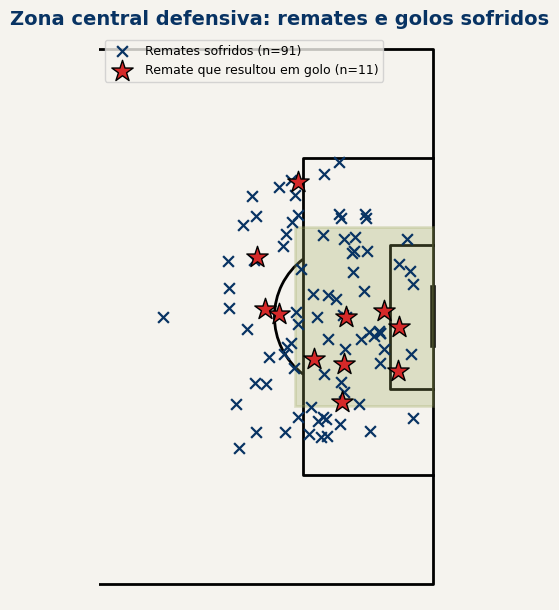

43 de 91 remates sofridos (47%) partem desta zona


In [16]:
c1 = (data["actionType"] == "SHOT").fillna(False)
c2 = (data["squadName"] != "Gil Vicente FC").fillna(False)
c3 = data["squadName"].notna()
remates = data[c1 & c2 & c3].copy()

c1g = (data["actionType"] == "GOAL").fillna(False)
golos_eventos = data[c1g & c2 & c3].copy()

remates_que_marcaram = []
for _, golo in golos_eventos.iterrows():
    match_id, t_golo, jogador = golo["matchId"], golo["gameTimeInSec"], golo["playerName"]
    candidatos = remates[
        (remates["matchId"] == match_id) & (remates["playerName"] == jogador)
        & (remates["gameTimeInSec"] < t_golo) & (remates["gameTimeInSec"] >= t_golo - 5)
    ]
    if len(candidatos) > 0:
        remates_que_marcaram.append(candidatos.sort_values("gameTimeInSec").iloc[-1])
remates_que_marcaram = pd.DataFrame(remates_que_marcaram) if remates_que_marcaram else pd.DataFrame()

fig, ax = plt.subplots(figsize=(8, 6.2))
pitch = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68,
              pitch_color=COR_FUNDO_CAMPO, line_color="#000000", half=False)
pitch.draw(ax=ax)
zona = Rectangle((35, -11.33), 52.5 - 35, 22.66, facecolor=COR_DOURADO, alpha=0.28, zorder=1, edgecolor=COR_DOURADO, linewidth=2)
ax.add_patch(zona)

indices_golo = remates_que_marcaram.index if len(remates_que_marcaram) > 0 else []
remates_sem_golo = remates[~remates.index.isin(indices_golo)]
ax.scatter(remates_sem_golo["startCoordinatesX"], remates_sem_golo["startCoordinatesY"], marker="x", s=60,
           color=COR_AZUL_MARINHO, linewidths=1.6, zorder=3, label=f"Remates sofridos (n={len(remates)})")
if len(remates_que_marcaram) > 0:
    ax.scatter(remates_que_marcaram["startCoordinatesX"], remates_que_marcaram["startCoordinatesY"], marker="*", s=260,
               color=COR_VERMELHO, edgecolors="black", linewidths=1, zorder=4, label=f"Remate que resultou em golo (n={len(remates_que_marcaram)})")
ax.set_xlim(10, 56); ax.set_ylim(-36, 36)
ax.set_title("Zona central defensiva: remates e golos sofridos", color=COR_AZUL_MARINHO)
ax.legend(loc="upper left", frameon=True, facecolor=COR_FUNDO_CAMPO, fontsize=9)
fig.patch.set_facecolor(COR_FUNDO_CAMPO)
plt.tight_layout()
plt.show()

def classificar_corredor(y):
    if pd.isna(y): return None
    if y < -11.33: return "ESQUERDA"
    elif y > 11.33: return "DIREITA"
    return "CENTRO"

remates["corredor"] = remates["startCoordinatesY"].apply(classificar_corredor)
n_remates_zona = ((remates["startCoordinatesX"] > 35) & (remates["corredor"] == "CENTRO")).sum()
print(f"{n_remates_zona} de {len(remates)} remates sofridos ({n_remates_zona/len(remates):.0%}) partem desta zona")


### De onde vêm as bolas que chegam a esta zona

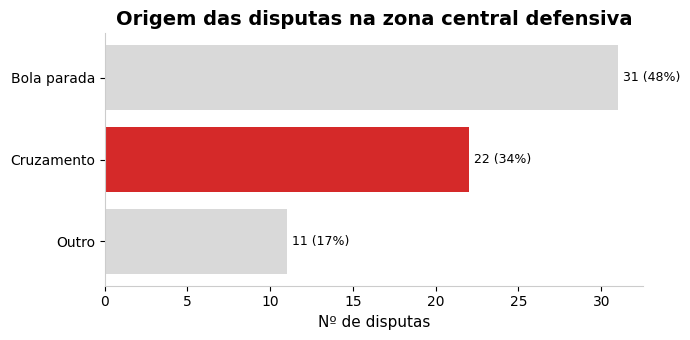

In [17]:
duelos_aereos = data[(data["action"] == "HEADER") & (data["actionType"] == "LOOSE_BALL_REGAIN")].copy()
duelos_terrestres = data[data["actionType"] == "GROUND_DUEL"].copy()
cols_duelo = ["matchId", "gameTimeInSec", "squadName", "startCoordinatesX", "startCoordinatesY"]
combinado_duelos = pd.concat([duelos_aereos[cols_duelo], duelos_terrestres[cols_duelo]], ignore_index=True)
combinado_duelos["corredor"] = combinado_duelos["startCoordinatesY"].apply(classificar_corredor)
zona_real = combinado_duelos[(combinado_duelos["startCoordinatesX"] > 35) & (combinado_duelos["corredor"] == "CENTRO")].copy()

origens = []
for _, duelo in zona_real.iterrows():
    match_id, t_duelo = duelo["matchId"], duelo["gameTimeInSec"]
    anterior = data[(data["matchId"] == match_id) & (data["gameTimeInSec"] < t_duelo)].tail(1)
    if len(anterior) == 0:
        origens.append("Sem contexto"); continue
    ev = anterior.iloc[0]
    if ev["action"] in ["HIGH_CROSS", "LOW_CROSS"]:
        origens.append("Cruzamento")
    elif ev["phase"] == "SET_PIECE":
        origens.append("Bola parada")
    else:
        origens.append("Outro")

origens_series = pd.Series(origens)
fig, ax = plt.subplots(figsize=(7, 3.5))
contagem = origens_series.value_counts()
cores = [COR_VERMELHO if o == "Cruzamento" else COR_CINZA_CLARO for o in contagem.index]
ax.barh(contagem.index, contagem.values, color=cores)
for i, v in enumerate(contagem.values):
    ax.text(v + 0.3, i, f"{v} ({v/len(origens_series):.0%})", va="center", fontsize=9)
ax.set_xlabel("Nº de disputas")
ax.set_title("Origem das disputas na zona central defensiva")
ax.invert_yaxis()
estilizar_eixos(ax)
plt.tight_layout()
plt.show()


A bola parada é a fonte individual mais comum (já coberta, do lado
ofensivo, no insight 1). Logo a seguir vem o **cruzamento**, o principal
vetor de entrega em jogo corrido. Testei primeiro se havia uma fraqueza na
disputa física direta desta zona (duelos aéreos/terrestres), mas comparado
com os 8 adversários nas suas próprias zonas equivalentes, o Gil Vicente não se
distinguia — é um padrão universal do futebol (Verificado na secção de tentativas). Por isso virei a pergunta:
onde é que o Gil Vicente responde **bem** à ameaça do cruzamento?


### A força geral em cruzamentos
Objetivo: Perceber como a equipa contêm os remates vindos de cruzamentos adversários.

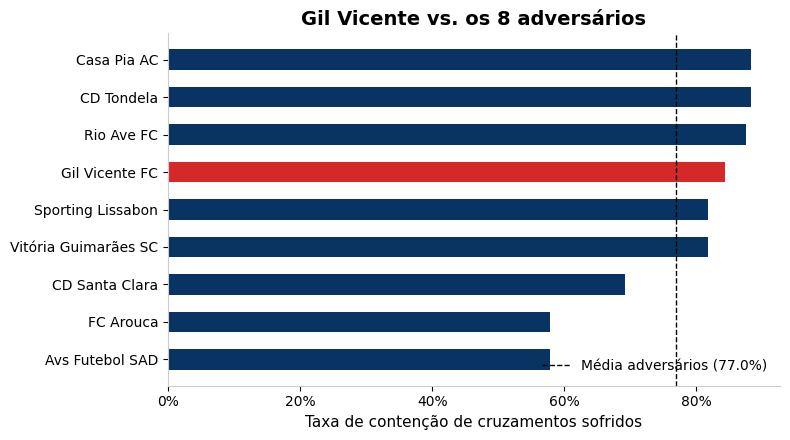

Gil Vicente: 84.3% | Média adversários: 77.0% | Diferença: +7.4pp


In [18]:
JANELA_CRUZAMENTO = 10

def taxa_contencao(eventos_df, data, janela=JANELA_CRUZAMENTO):
    n_contidos = 0
    for _, ev in eventos_df.iterrows():
        match_id, t_ev = ev["matchId"], ev["gameTimeInSec"]
        equipa_atacante = ev["squadName"]
        c1 = (data["matchId"] == match_id).fillna(False)
        c2 = (data["gameTimeInSec"] >= t_ev).fillna(False)
        c3 = (data["gameTimeInSec"] <= t_ev + janela).fillna(False)
        janela_df = data[c1 & c2 & c3]
        c4 = (janela_df["actionType"] == "SHOT").fillna(False)
        c5 = (janela_df["squadName"] == equipa_atacante).fillna(False)
        if not (c4 & c5).any():
            n_contidos += 1
    return n_contidos, len(eventos_df)

c1 = data["action"].isin(["HIGH_CROSS", "LOW_CROSS"]).fillna(False)
c2 = (data["squadName"] != "Gil Vicente FC").fillna(False)
c3 = data["squadName"].notna()
cruzamentos_adv = data[c1 & c2 & c3]
n_gv, total_gv = taxa_contencao(cruzamentos_adv, data)
taxa_gv = n_gv / total_gv

resultados_cruz = []
for match_id, nome in mapa_adversario.items():
    c1b = (data["matchId"] == match_id).fillna(False)
    c2b = data["action"].isin(["HIGH_CROSS", "LOW_CROSS"]).fillna(False)
    c3b = (data["squadName"] == "Gil Vicente FC").fillna(False)
    n, total = taxa_contencao(data[c1b & c2b & c3b], data)
    resultados_cruz.append({"adversario": nome, "n_contidos": n, "n_total": total, "taxa": n / total if total else None})
res_cruz_df = pd.DataFrame(resultados_cruz)
taxa_media_adv = res_cruz_df["n_contidos"].sum() / res_cruz_df["n_total"].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
equipas = list(res_cruz_df["adversario"]) + ["Gil Vicente FC"]
taxas = list(res_cruz_df["taxa"]) + [taxa_gv]
cores = [COR_AZUL_MARINHO] * len(res_cruz_df) + [COR_VERMELHO]
import numpy as np
ordem = np.argsort(taxas)
ax.barh([equipas[i] for i in ordem], [taxas[i] for i in ordem], color=[cores[i] for i in ordem], height=0.55)
ax.axvline(taxa_media_adv, color="black", linestyle="--", linewidth=1, label=f"Média adversários ({taxa_media_adv:.1%})")
ax.set_xlabel("Taxa de contenção de cruzamentos sofridos")
ax.set_title("Gil Vicente vs. os 8 adversários")
ax.xaxis.set_major_formatter(lambda v, pos: f"{v:.0%}")
ax.legend(frameon=False, loc="lower right")
estilizar_eixos(ax)
plt.tight_layout()
plt.show()

print(f"Gil Vicente: {taxa_gv:.1%} | Média adversários: {taxa_media_adv:.1%} | Diferença: {(taxa_gv-taxa_media_adv)*100:+.1f}pp")


**+7.4 pontos percentuais acima da média** — testado e confirmado que se
mantém (aproximandamente a mesma diferença) mesmo excluindo o Sporting CP, o adversário de
nível claramente superior, para garantir que o resultado não estava
distorcido por um único jogo.


### Mas há uma exceção: o cruzamento rasteiro

A força geral não é uniforme por tipo de entrega.


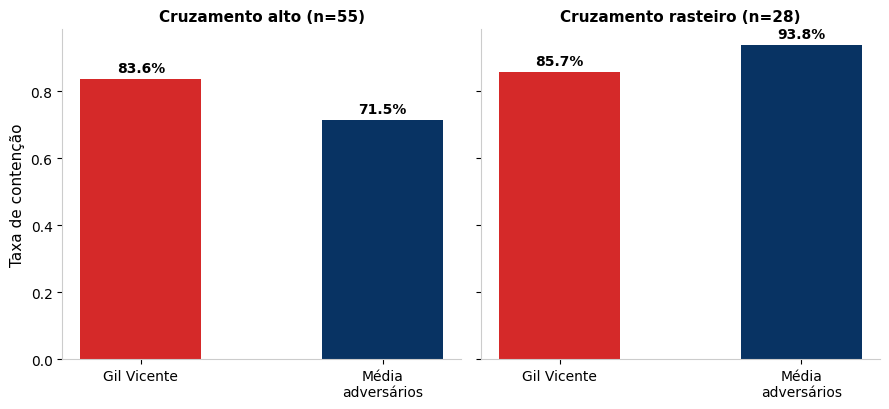

Alto: Gil Vicente 83.6% vs média 71.5% (+12.2pp)
Rasteiro: Gil Vicente 85.7% vs média 93.8% (-8.0pp)


In [19]:
def contencao_por_tipo(tipo_acao):
    c1 = (data["action"] == tipo_acao).fillna(False)
    c2 = (data["squadName"] != "Gil Vicente FC").fillna(False)
    c3 = data["squadName"].notna()
    n_gv, total_gv = taxa_contencao(data[c1 & c2 & c3], data)

    taxas_adv = []
    for match_id in mapa_adversario:
        c1b = (data["matchId"] == match_id).fillna(False)
        c2b = (data["action"] == tipo_acao).fillna(False)
        c3b = (data["squadName"] == "Gil Vicente FC").fillna(False)
        sub = data[c1b & c2b & c3b]
        if len(sub) > 0:
            n, total = taxa_contencao(sub, data)
            taxas_adv.append(n / total)
    return n_gv / total_gv, sum(taxas_adv) / len(taxas_adv), total_gv

taxa_gv_alto, taxa_adv_alto, n_alto = contencao_por_tipo("HIGH_CROSS")
taxa_gv_rasteiro, taxa_adv_rasteiro, n_rasteiro = contencao_por_tipo("LOW_CROSS")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)
for ax, titulo, gv, adv, n in [
    (axes[0], f"Cruzamento alto (n={n_alto})", taxa_gv_alto, taxa_adv_alto, n_alto),
    (axes[1], f"Cruzamento rasteiro (n={n_rasteiro})", taxa_gv_rasteiro, taxa_adv_rasteiro, n_rasteiro),
]:
    ax.bar(["Gil Vicente", "Média\nadversários"], [gv, adv], color=[COR_VERMELHO, COR_AZUL_MARINHO], width=0.5)
    for i, v in enumerate([gv, adv]):
        ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title(titulo, fontsize=11)
    estilizar_eixos(ax)
axes[0].set_ylabel("Taxa de contenção")
plt.tight_layout()
plt.show()

print(f"Alto: Gil Vicente {taxa_gv_alto:.1%} vs média {taxa_adv_alto:.1%} ({(taxa_gv_alto-taxa_adv_alto)*100:+.1f}pp)")
print(f"Rasteiro: Gil Vicente {taxa_gv_rasteiro:.1%} vs média {taxa_adv_rasteiro:.1%} ({(taxa_gv_rasteiro-taxa_adv_rasteiro)*100:+.1f}pp)")


No cruzamento **alto**, o Gil Vicente está bem acima da média — a vantagem geral vem
quase toda daqui. No cruzamento **rasteiro**, o Gil Vicente fica **abaixo** da média:
mais rápido e direto, dá menos tempo à equipa para se reorganizar
coletivamente.


### De que lado e a que profundidade

In [ ]:
BALIZA_GV_X = 52.5

c1 = (data["action"] == "LOW_CROSS").fillna(False)
c2 = (data["squadName"] != "Gil Vicente FC").fillna(False)
c3 = data["squadName"].notna()
low_cross_vs_gv = data[c1 & c2 & c3].copy()

low_cross_vs_gv["lado"] = low_cross_vs_gv["startCoordinatesY"].apply(lambda y: "Esquerda" if y < 0 else "Direita")

low_cross_vs_gv["profundidade"] = BALIZA_GV_X - low_cross_vs_gv["startCoordinatesX"]

def avaliar_perigo(subset):
    n_com_remate, xg_total = 0, 0
    for _, ev in subset.iterrows():
        match_id, t_ev = ev["matchId"], ev["gameTimeInSec"]
        c1b = (data["matchId"] == match_id).fillna(False)
        c2b = (data["gameTimeInSec"] >= t_ev).fillna(False)
        c3b = (data["gameTimeInSec"] <= t_ev + 10).fillna(False)
        janela = data[c1b & c2b & c3b]
        c4b = (janela["actionType"] == "SHOT").fillna(False)
        c5b = (janela["squadName"] == ev["squadName"]).fillna(False)
        remates_janela = janela[c4b & c5b]
        if len(remates_janela) > 0:
            n_com_remate += 1
            xg_total += remates_janela["SHOT_XG"].sum()
    return n_com_remate / len(subset) if len(subset) else None, xg_total

q1, q2 = low_cross_vs_gv["profundidade"].quantile([0.33, 0.66])

linhas = []
for lado in ["Esquerda", "Direita"]:
    sub = low_cross_vs_gv[low_cross_vs_gv["lado"] == lado]
    taxa, xg = avaliar_perigo(sub)
    linhas.append({"dimensão": "Lado", "categoria": lado, "n": len(sub), "taxa_remate": taxa, "xg_total": xg})

for nome, cond in [
    (f"Linha de fundo (≤{q1:.1f}m)", low_cross_vs_gv["profundidade"] <= q1),
    (f"Zona intermédia ({q1:.1f}–{q2:.1f}m)", (low_cross_vs_gv["profundidade"] > q1) & (low_cross_vs_gv["profundidade"] <= q2)),
    (f"Mais recuado (>{q2:.1f}m)", low_cross_vs_gv["profundidade"] > q2),
]:
    sub = low_cross_vs_gv[cond]
    taxa, xg = avaliar_perigo(sub)
    linhas.append({"dimensão": "Profundidade", "categoria": nome, "n": len(sub), "taxa_remate": taxa, "xg_total": xg})

tabela_lado_prof = pd.DataFrame(linhas)
tabela_lado_prof["taxa_remate"] = tabela_lado_prof["taxa_remate"].apply(lambda v: f"{v:.1%}" if v is not None else "—")
tabela_lado_prof


,dimensão,categoria,n,taxa_remate,xg_total
0,Lado,Esquerda,12,25.0%,0.51769
1,Lado,Direita,16,6.2%,0.05103
2,Profundidade,Linha de fundo (≤5.4m),9,0.0%,0.00000
3,Profundidade,Zona intermédia (5.4–12.1m),9,11.1%,0.05103
4,Profundidade,Mais recuado (>12.1m),10,30.0%,0.51769


Os cruzamentos rasteiros sofridos pelo **flanco esquerdo** são muito mais perigosos que
os da direita. E os batidos **mesmo da linha de fundo** são muito
bem controlados (0% de remates); os de uma **zona mais recuada** são os mais
perigosos, provavelmente por serem mais difíceis de antecipar.

**Nota:** profundidade medida como distância à
linha de fundo.


### Síntese — Insight 2

**Questão:** em que momento defensivo o Gil Vicente tem uma vantagem
mensurável face aos adversários?

**Evidência:** contenção de cruzamentos de 84.3%, +7.4pp acima da média dos
8 adversários — confirmado com e sem o Sporting CP. Mas essa força
concentra-se no cruzamento alto; no rasteiro o Gil Vicente fica abaixo da média,
sobretudo vindo do flanco esquerdo e de zona mais recuada da linha de fundo.

**Interpretação futebolística:** a vantagem do Gil Vicente nos cruzamentos
altos não vem de ganhar mais duelos aéreos do que qualquer outra equipa —
testámos isso especificamente, e a taxa de vitória em duelos na própria área
(89.1%) está, na verdade, ligeiramente abaixo da média dos adversários
(93.6%), praticamente equivalente. O que distingue o Gil Vicente é o que acontece a
seguir: mesmo com uma capacidade de duelo "normal", a equipa consegue conter
o cruzamento acima da média — o que aponta para organização coletiva e
tempo de reação, não para superioridade física no primeiro contacto. Um
cruzamento alto dá tempo à equipa para se reorganizar coletivamente (cobrir,
aliviar a segunda bola) mesmo que o duelo individual não seja excecional. O
cruzamento rasteiro retira precisamente esse tempo — e é aí, sem margem para
compensação coletiva, que a capacidade "normal" de duelo do Gil Vicente deixa de
chegar, explicando a queda para abaixo da média.

**Aplicação prática para uma equipa técnica:** instruir os alas/avançados a
preferir o cruzamento rasteiro (em vez do cruzamento alto clássico) sempre
que cheguem à zona de cruzamento — de preferência a partir do corredor
direito do próprio ataque (que corresponde ao flanco esquerdo do Gil
Vicente, onde identificámos a fraqueza) e de uma zona a mais de 12.1m de
profundidade da linha de fundo, não colada a ela. Como quase metade destas
situações surgem em jogo organizado, a equipa pode procurar criar
deliberadamente esta situação, não só aproveitá-la quando surge por acaso.

**Limitações:** cada adversário só tem 1 jogo de amostra; a decomposição por
lado/profundidade do cruzamento rasteiro assenta em só 28 casos — direção
plausível, mas não uma certeza estatística.


---
## 3. Metodologia e limitações gerais

- **Amostra:** 8 jogos, época 2025/26. Qualquer teste estatístico aqui é
  indicativo, não conclusivo.
- **Comparação com adversários:** cada um contribui só 1 jogo — a "média dos
  adversários" é uma referência de contexto, não uma prova estatística
  robusta, ainda por cima todos contra o mesmo clube (Gil Vicente).
- **Métricas nativas do IMPECT** (pxT, zonas pré-classificadas) usadas como
  estão, sem verificação da fórmula exata do fornecedor.
